In [12]:
from typing import Optional
from ollama import chat # type: ignore
from pydantic import BaseModel, Field # type: ignore
import json
import tiktoken
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import pandas as pd

def nd(arr):
    return np.asarray(arr).reshape(-1)

def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(**{"aspect": "equal", "xlim": lims, "ylim": lims})
    return ax
fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'


In [2]:
def load_evidence(fn, ds_name):
    df = pd.read_json(fn)
    # Unwrap the 'source' column (contains a dictionary) into separate columns
    source_df = df['source'].apply(pd.Series)
    extracted_df = df['extracted'].apply(pd.Series).add_prefix('extracted_')
    # derived_df = df['derived'].apply(pd.Series).add_prefix('derived_')
    # Combine the original DataFrame with the unwrapped columns
    # df = pd.concat([df.drop(columns=['source', 'extracted', 'derived']), source_df, extracted_df, derived_df], axis=1)
    df = pd.concat([df.drop(columns=['source', 'extracted']), source_df, extracted_df], axis=1)
    df["ds"] = ds_name
    del df["derived"]
    return df

import hashlib

def short_hash(s: str) -> str:
    """Generate a 7-character hash from a given string."""
    return hashlib.sha256(s.encode()).hexdigest()[:7]

# Example usage
print(short_hash("mystring"))  # Example output: 'aaf4c61'

bd3ff47


In [3]:
folder_name = "evidence_llm_llama3.2_MarkerGeneListStrict_4efcc22"

In [10]:
llm = load_evidence(os.path.join(folder_name, "evidence.json"), "llm")
with open(os.path.join(folder_name, "model_metadata.json")) as f:
    model_metadata = json.load(f)

In [11]:
model_metadata

{'model_id': 'llama3.2',
 'system_prompt': '\nYou are an expert in genomics analyzing scientific literature to extract marker genes for different cell types. \n\nYour goal is to identify and structure marker gene data from the given text. For each marker gene mentioned, extract:\n- The **gene name** (marker_gene_name).\n- The **cell type** it is associated with (cell_type_name).\n\nThe data must be extracted as written in the text, without any modifications.\n\nReturn the results in **structured JSON format** with the following schema:\n{\n    "genes": [\n        {\n            "cell_type_name": "Neuron",\n            "marker_gene_name": "GeneX",\n        },\n        ...\n    ]\n}\n',
 'system_prompt_hash': '4efcc22',
 'data_model': 'MarkerGeneListStrict'}

In [5]:
fns = glob.glob("../../data/*/evidence_human/evidence.json")
dfs = []
for fn in fns:
    ds_name = fn.split("/")[-3]
    dfs.append(load_evidence(fn, ds_name))
df = pd.concat(dfs)
hmn = df.query("source_type == 'text'").copy()

In [6]:

common_src = np.intersect1d(hmn.source_rationale.unique(), llm.source_rationale.unique())

/var/folders/89/1b_bcy3s39g4nkyxbdxvgzt40000gn/T/ipykernel_17967/2793447428.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


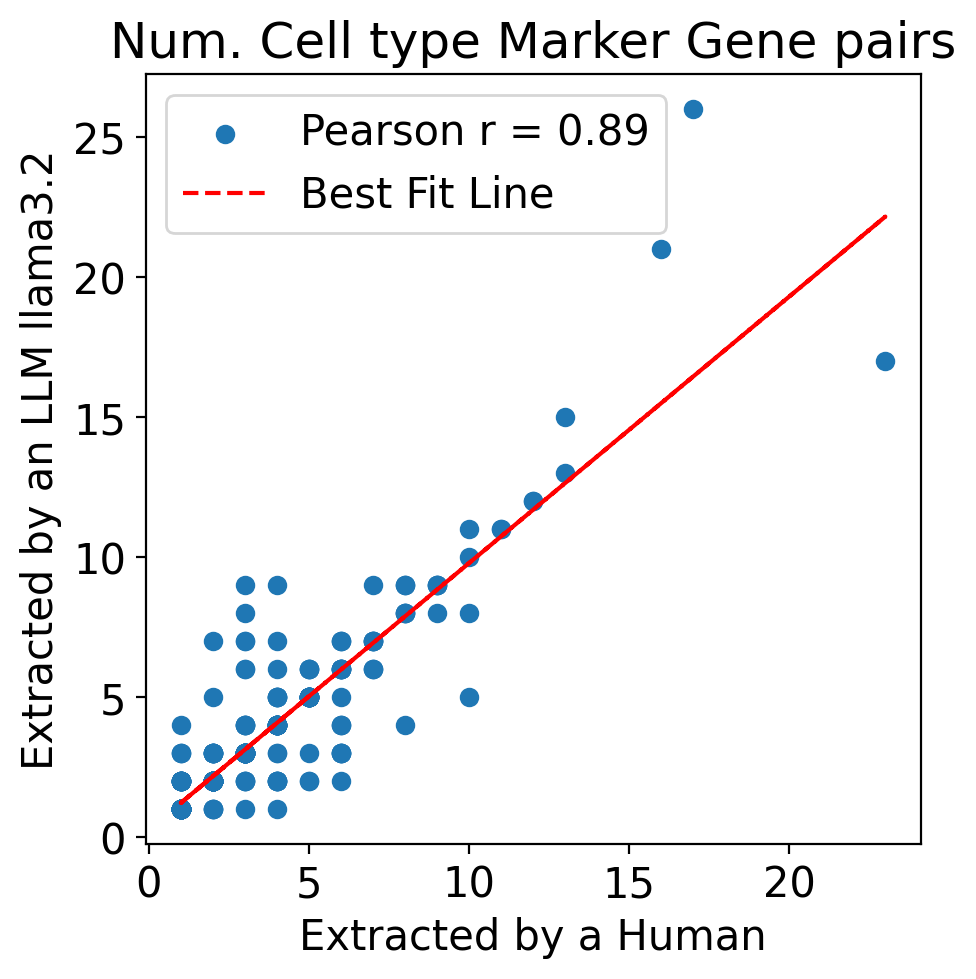

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))

x = hmn.groupby("source_rationale")["extracted_cell_type_label"].count().sort_index()[common_src].values
y = llm.groupby("source_rationale")["extracted_cell_type_label"].count().sort_index()[common_src].values

# Compute Pearson correlation
r, _ = pearsonr(x, y)

# Scatter plot
ax.scatter(x, y, label=f"Pearson r = {r:.2f}")

# Fit line of best fit
m, b = np.polyfit(x, y, 1)
ax.plot(x, m*x + b, color='red', linestyle='--', label="Best Fit Line")

# Labels and legend
ax.set(**{
    "xlabel": "Extracted by a Human",
    "ylabel": f"Extracted by an LLM {model_metadata['model_id']}",
    "title": "Num. Cell type Marker Gene pairs"
})
ax.legend()

fig.show()

In [14]:
folder_name

'evidence_llm_llama3.2_MarkerGeneListStrict_4efcc22'

In [15]:
tmp = pd.DataFrame({"src": common_src, "human": x, "llm": y})

In [16]:
tmp["same"] = tmp["human"] == tmp["llm"]

In [17]:
tmp.query("same == False")

,src,human,llm,same
0,"Finally, we noted that CALM2 was negatively c...",5,2,False
14,ANXA1 is a marker of cells undergoing inflamma...,3,2,False
17,Although both cells clusters expressed typical...,6,7,False
18,Although cells in SPG1 and SPG2 are similar to...,8,9,False
19,"Although not the case at mRNA level, VSIG4 was...",4,2,False
...,...,...,...,...
276,"[...] while SIX1+ myoprogenitors (cluster 9),4...",6,3,False
278,and EVT_8W_3 cells displayed a strong similari...,8,4,False
280,"cDC2Bs expressed MIF, IL-18, IL-1β and TNFSF9 ...",3,4,False
289,"ndeed, TREM2-expressing human LAM cells consti...",9,8,False


In [19]:
tmp.iloc[291]

src      one cluster of NK-like cells discerned by expr...
human                                                    7
llm                                                      6
same                                                 False
Name: 291, dtype: object

In [20]:
print(common_src[291])

one cluster of NK-like cells discerned by expression of IL7R, SELL and CD2 similar to previously described CD56bright immature NK (iNK) cells in human peripheral tissues, and a population of NK-like cells distinguished by expression of CXCR6, KLRC1 and GZMK consistent with tissue-resident NK (trNK) cells described in the human liver


In [21]:
src = f"'{common_src[291]}'"

In [28]:
print(src)

'one cluster of NK-like cells discerned by expression of IL7R, SELL and CD2 similar to previously described CD56bright immature NK (iNK) cells in human peripheral tissues, and a population of NK-like cells distinguished by expression of CXCR6, KLRC1 and GZMK consistent with tissue-resident NK (trNK) cells described in the human liver'


In [23]:
llm.query(f"source_rationale == {src}")[["extracted_cell_type_label", "extracted_feature_name"]]

,extracted_cell_type_label,extracted_feature_name
542,NK-like cells,IL7R
543,NK-like cells,SELL
544,NK-like cells,CD2
545,trNK cells,CXCR6
546,trNK cells,KLRC1
547,trNK cells,GZMK


In [24]:
hmn.query(f"source_rationale == {src}")[["extracted_cell_type_label", "extracted_feature_name", "ds", "source_rationale"]]

,extracted_cell_type_label,extracted_feature_name,ds,source_rationale
9,NK-like cells,IL7R,adipose_Hildreth2021,one cluster of NK-like cells discerned by expr...
10,NK-like cells,SELL,adipose_Hildreth2021,one cluster of NK-like cells discerned by expr...
11,NK-like cells,CD2,adipose_Hildreth2021,one cluster of NK-like cells discerned by expr...
12,immature NK (iNK) cells,CD56,adipose_Hildreth2021,one cluster of NK-like cells discerned by expr...
13,NK-like cells,CXCR6,adipose_Hildreth2021,one cluster of NK-like cells discerned by expr...
14,NK-like cells,KLRC1,adipose_Hildreth2021,one cluster of NK-like cells discerned by expr...
15,NK-like cells,GZMK,adipose_Hildreth2021,one cluster of NK-like cells discerned by expr...


In [ ]:
src

"'After doublet removal and quality filtering, we considered a total of 197,721 cells (106,469 from PG and 91,252 from ING), identifying all cell types observed in human WAT (Fig. 2c, d, Supplementary Table 2) with the addition of distinct male and female epithelial populations (Dcdc2a+ and Erbb4+, respectively)'"

In [29]:
hmn.shape

(1066, 10)

In [30]:
hmn.ds.nunique()

19